In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/regularized-linear-regression-project-tutorial/main/demographic_health_data.csv")
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [2]:
df.shape

(3140, 108)

In [3]:
print(df.columns.tolist())

['fips', 'TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct', '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop', '30-39', '30-39 y/o % of total pop', '40-49', '40-49 y/o % of total pop', '50-59', '50-59 y/o % of total pop', '60-69', '60-69 y/o % of total pop', '70-79', '70-79 y/o % of total pop', '80+', '80+ y/o % of total pop', 'White-alone pop', '% White-alone', 'Black-alone pop', '% Black-alone', 'Native American/American Indian-alone pop', '% NA/AI-alone', 'Asian-alone pop', '% Asian-alone', 'Hawaiian/Pacific Islander-alone pop', '% Hawaiian/PI-alone', 'Two or more races pop', '% Two or more races', 'POP_ESTIMATE_2018', 'N_POP_CHG_2018', 'GQ_ESTIMATES_2018', 'R_birth_2018', 'R_death_2018', 'R_NATURAL_INC_2018', 'R_INTERNATIONAL_MIG_2018', 'R_DOMESTIC_MIG_2018', 'R_NET_MIG_2018', 'Less than a high school diploma 2014-18', 'High school diploma only 2014-18', "Some college or associate's degree 2014-18", "Bachelor's degree or higher 2014-18", 'Percent of adults with les

In [4]:
duplicados = df.duplicated()
num_duplicados = duplicados.sum()
print(num_duplicados)

0


/tmp/ipykernel_2180/484887886.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axis[0], data=df[df['COUNTY_NAME'].isin(top_counties)],
/tmp/ipykernel_2180/484887886.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axis[1], data=df[df['STATE_NAME'].isin(top_states)],


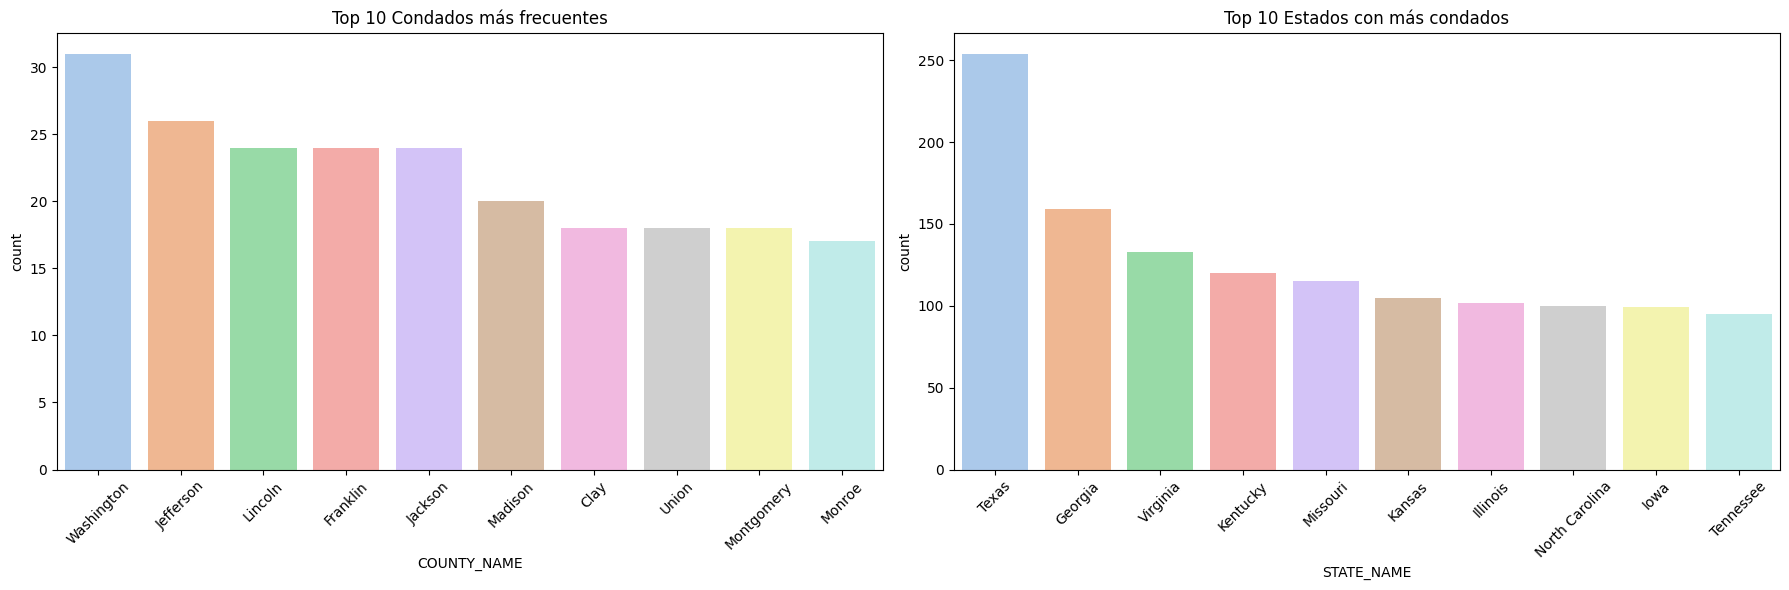

In [5]:

top_counties = df['COUNTY_NAME'].value_counts().nlargest(10).index
top_states = df['STATE_NAME'].value_counts().nlargest(10).index

fig, axis = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(ax=axis[0], data=df[df['COUNTY_NAME'].isin(top_counties)],
              x="COUNTY_NAME", palette='pastel', order=top_counties)
axis[0].set_title("Top 10 Condados más frecuentes")
axis[0].tick_params(axis='x', rotation=45)

sns.countplot(ax=axis[1], data=df[df['STATE_NAME'].isin(top_states)],
              x="STATE_NAME", palette='pastel', order=top_states)
axis[1].set_title("Top 10 Estados con más condados")
axis[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

He agrupado los más comunes por que si no al haber tantos datos no se veía bien,

In [6]:
int_columns = df.select_dtypes(include=['int64']).columns.tolist()

# Mostrar las columnas de tipo int64
print("Columnas de tipo int64:")
print(int_columns)

Columnas de tipo int64:
['fips', 'TOT_POP', '0-9', '19-Oct', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+', 'White-alone pop', 'Black-alone pop', 'Native American/American Indian-alone pop', 'Asian-alone pop', 'Hawaiian/Pacific Islander-alone pop', 'Two or more races pop', 'POP_ESTIMATE_2018', 'N_POP_CHG_2018', 'GQ_ESTIMATES_2018', 'Less than a high school diploma 2014-18', 'High school diploma only 2014-18', "Some college or associate's degree 2014-18", "Bachelor's degree or higher 2014-18", 'POVALL_2018', 'MEDHHINC_2018', 'CI90LBINC_2018', 'CI90UBINC_2018', 'Civilian_labor_force_2018', 'Employed_2018', 'Unemployed_2018', 'Median_Household_Income_2018', 'ICU Beds_x', 'Total Population', 'Population Aged 60+', 'STATE_FIPS', 'CNTY_FIPS', 'county_pop2018_18 and older', 'anycondition_number', 'Obesity_number', 'Heart disease_number', 'COPD_number', 'diabetes_number', 'CKD_number', 'Urban_rural_code']


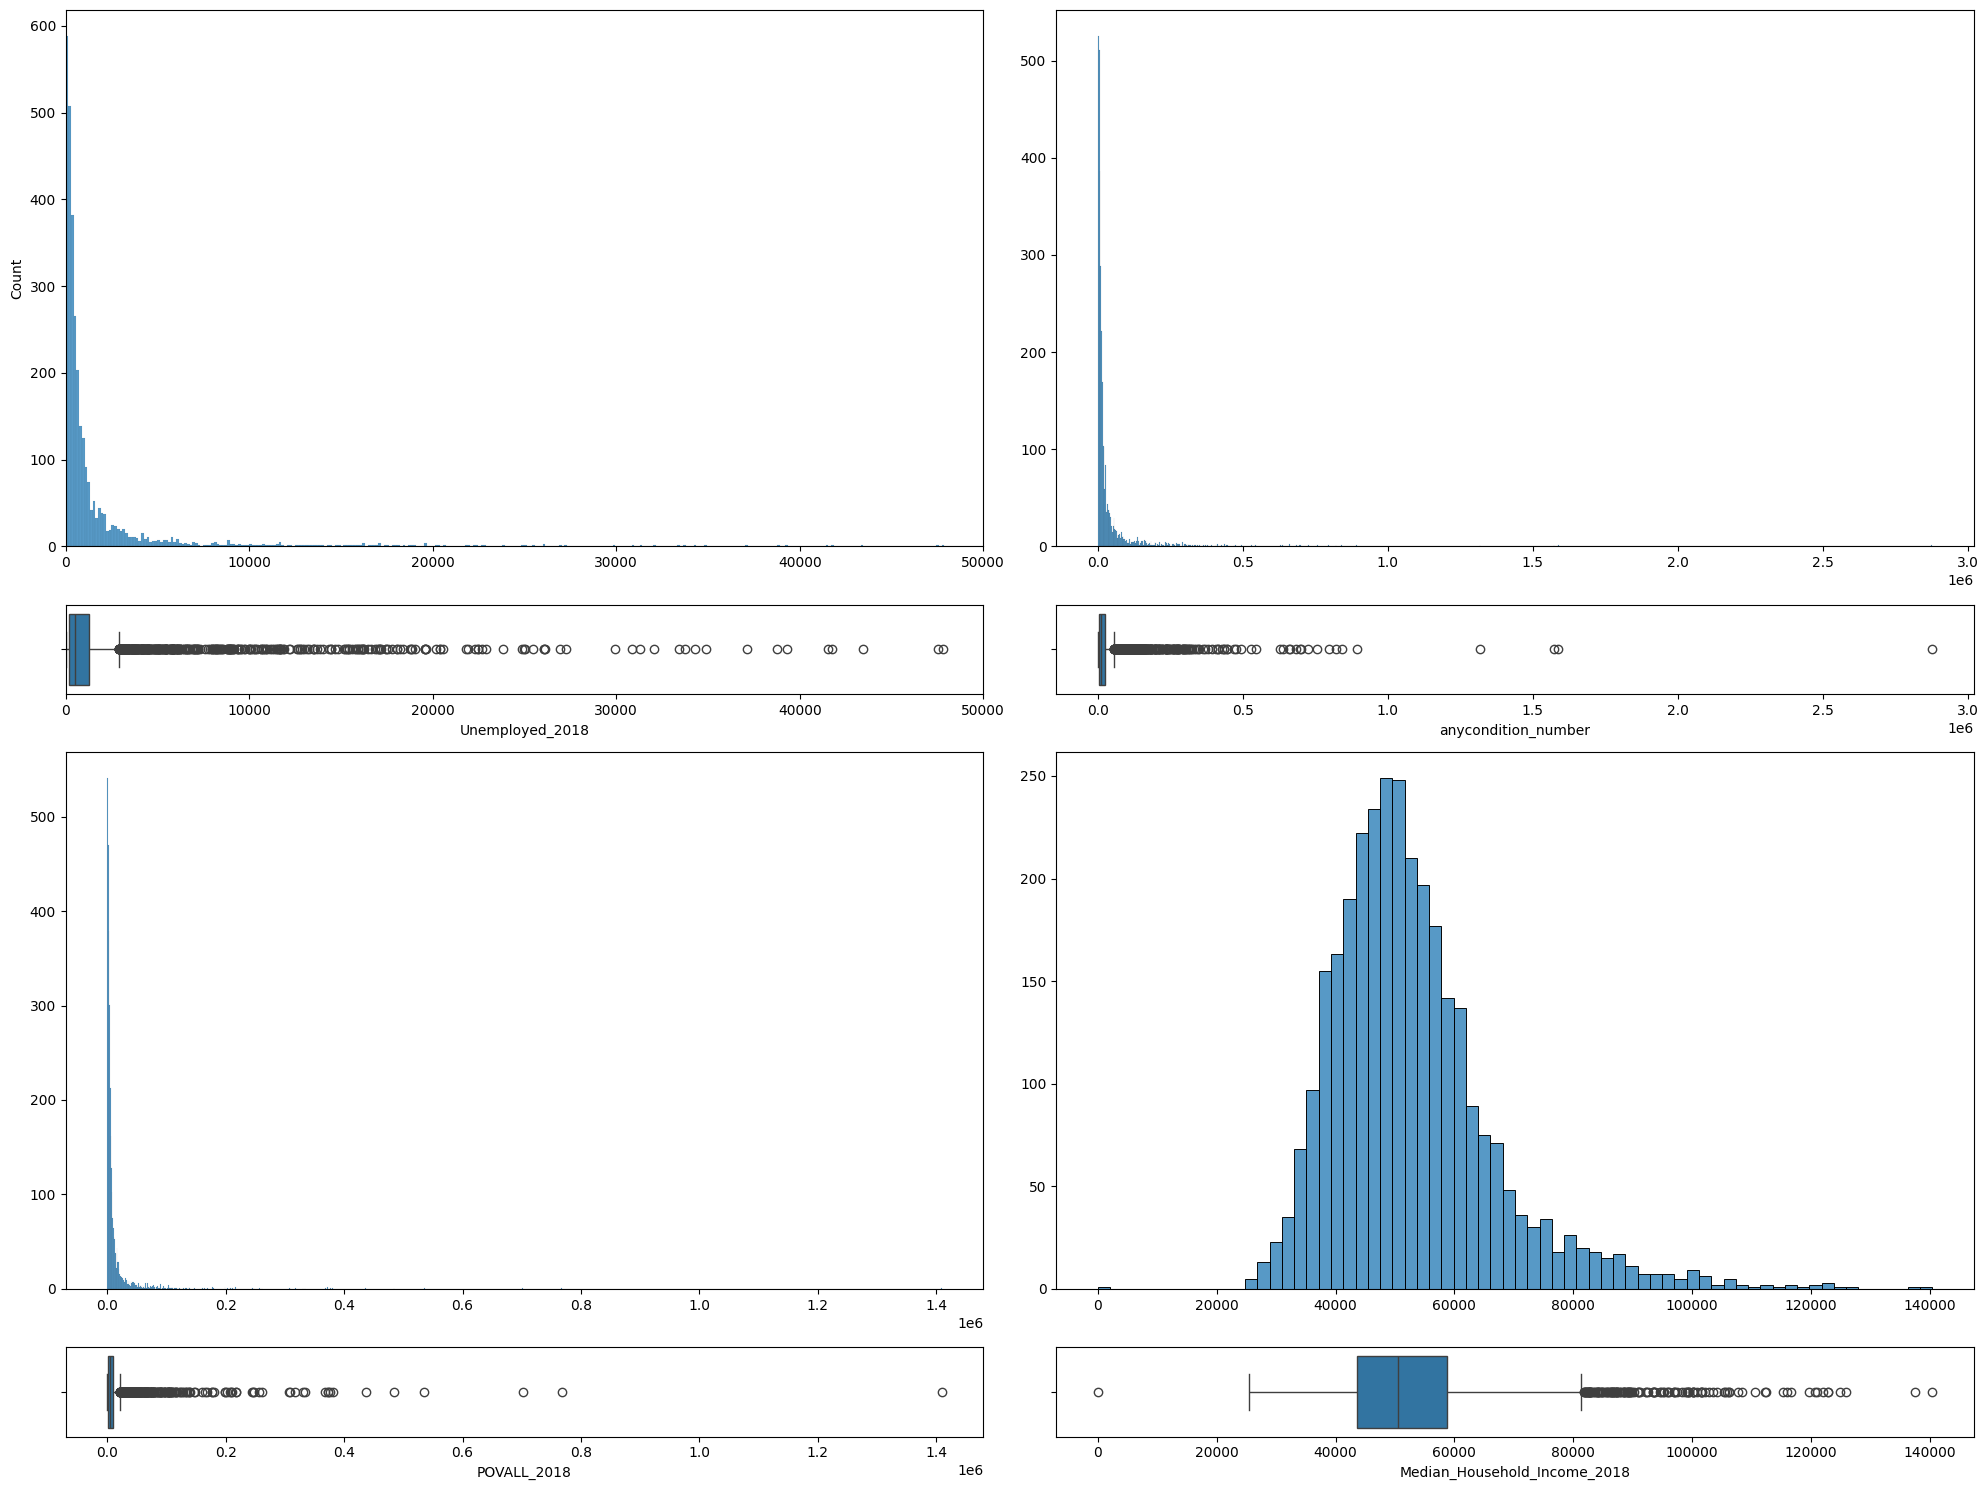

In [7]:
fig, axis = plt.subplots(4, 2, figsize = (20, 15), gridspec_kw = {"height_ratios": [6, 1, 6, 1]})

sns.histplot(ax = axis[0, 0], data = df, x = "Unemployed_2018").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = df, x = "Unemployed_2018")
axis[0, 0].set_xlim(0, 50000)
axis[1, 0].set_xlim(0, 50000)

sns.histplot(ax = axis[0, 1], data = df, x = "anycondition_number").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = df, x = "anycondition_number")


sns.histplot(ax = axis[2, 0], data = df, x = "POVALL_2018").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 0], data = df, x = "POVALL_2018")

sns.histplot(ax = axis[2, 1], data = df, x = "Median_Household_Income_2018").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 1], data = df, x = "Median_Household_Income_2018")

plt.tight_layout()

plt.show()

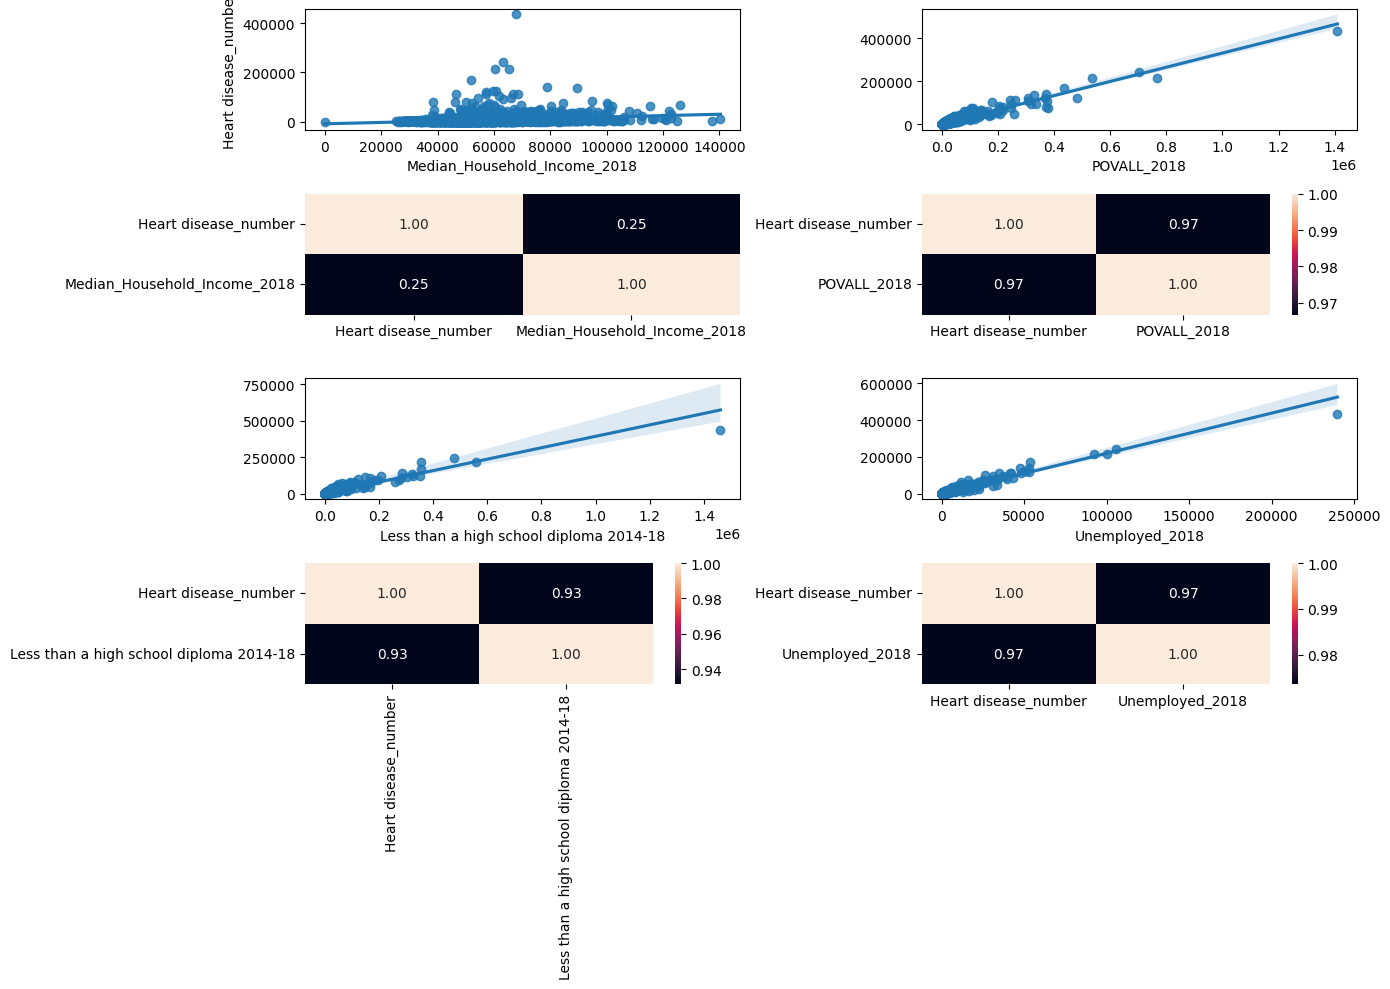

In [8]:
fig, axis = plt.subplots(4, 2, figsize = (14, 10))

sns.regplot(ax = axis[0, 0], data = df, x = "Median_Household_Income_2018", y = "Heart disease_number")
sns.heatmap(df[["Heart disease_number", "Median_Household_Income_2018"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = df, x = "POVALL_2018", y = "Heart disease_number").set(ylabel=None)
sns.heatmap(df[["Heart disease_number", "POVALL_2018"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])

sns.regplot(ax = axis[2, 0], data = df, x = "Less than a high school diploma 2014-18", y = "Heart disease_number").set(ylabel=None)
sns.heatmap(df[["Heart disease_number", "Less than a high school diploma 2014-18"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 0])

sns.regplot(ax = axis[2, 1], data = df, x = "Unemployed_2018", y = "Heart disease_number").set(ylabel=None)
sns.heatmap(df[["Heart disease_number", "Unemployed_2018"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 1])


plt.tight_layout()


plt.show()

/tmp/ipykernel_2180/2040570969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax = axis[0], data = df[df["COUNTY_NAME"].isin(top_counties)],
/tmp/ipykernel_2180/2040570969.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax = axis[1], data = df[df["STATE_NAME"].isin(top_states)],


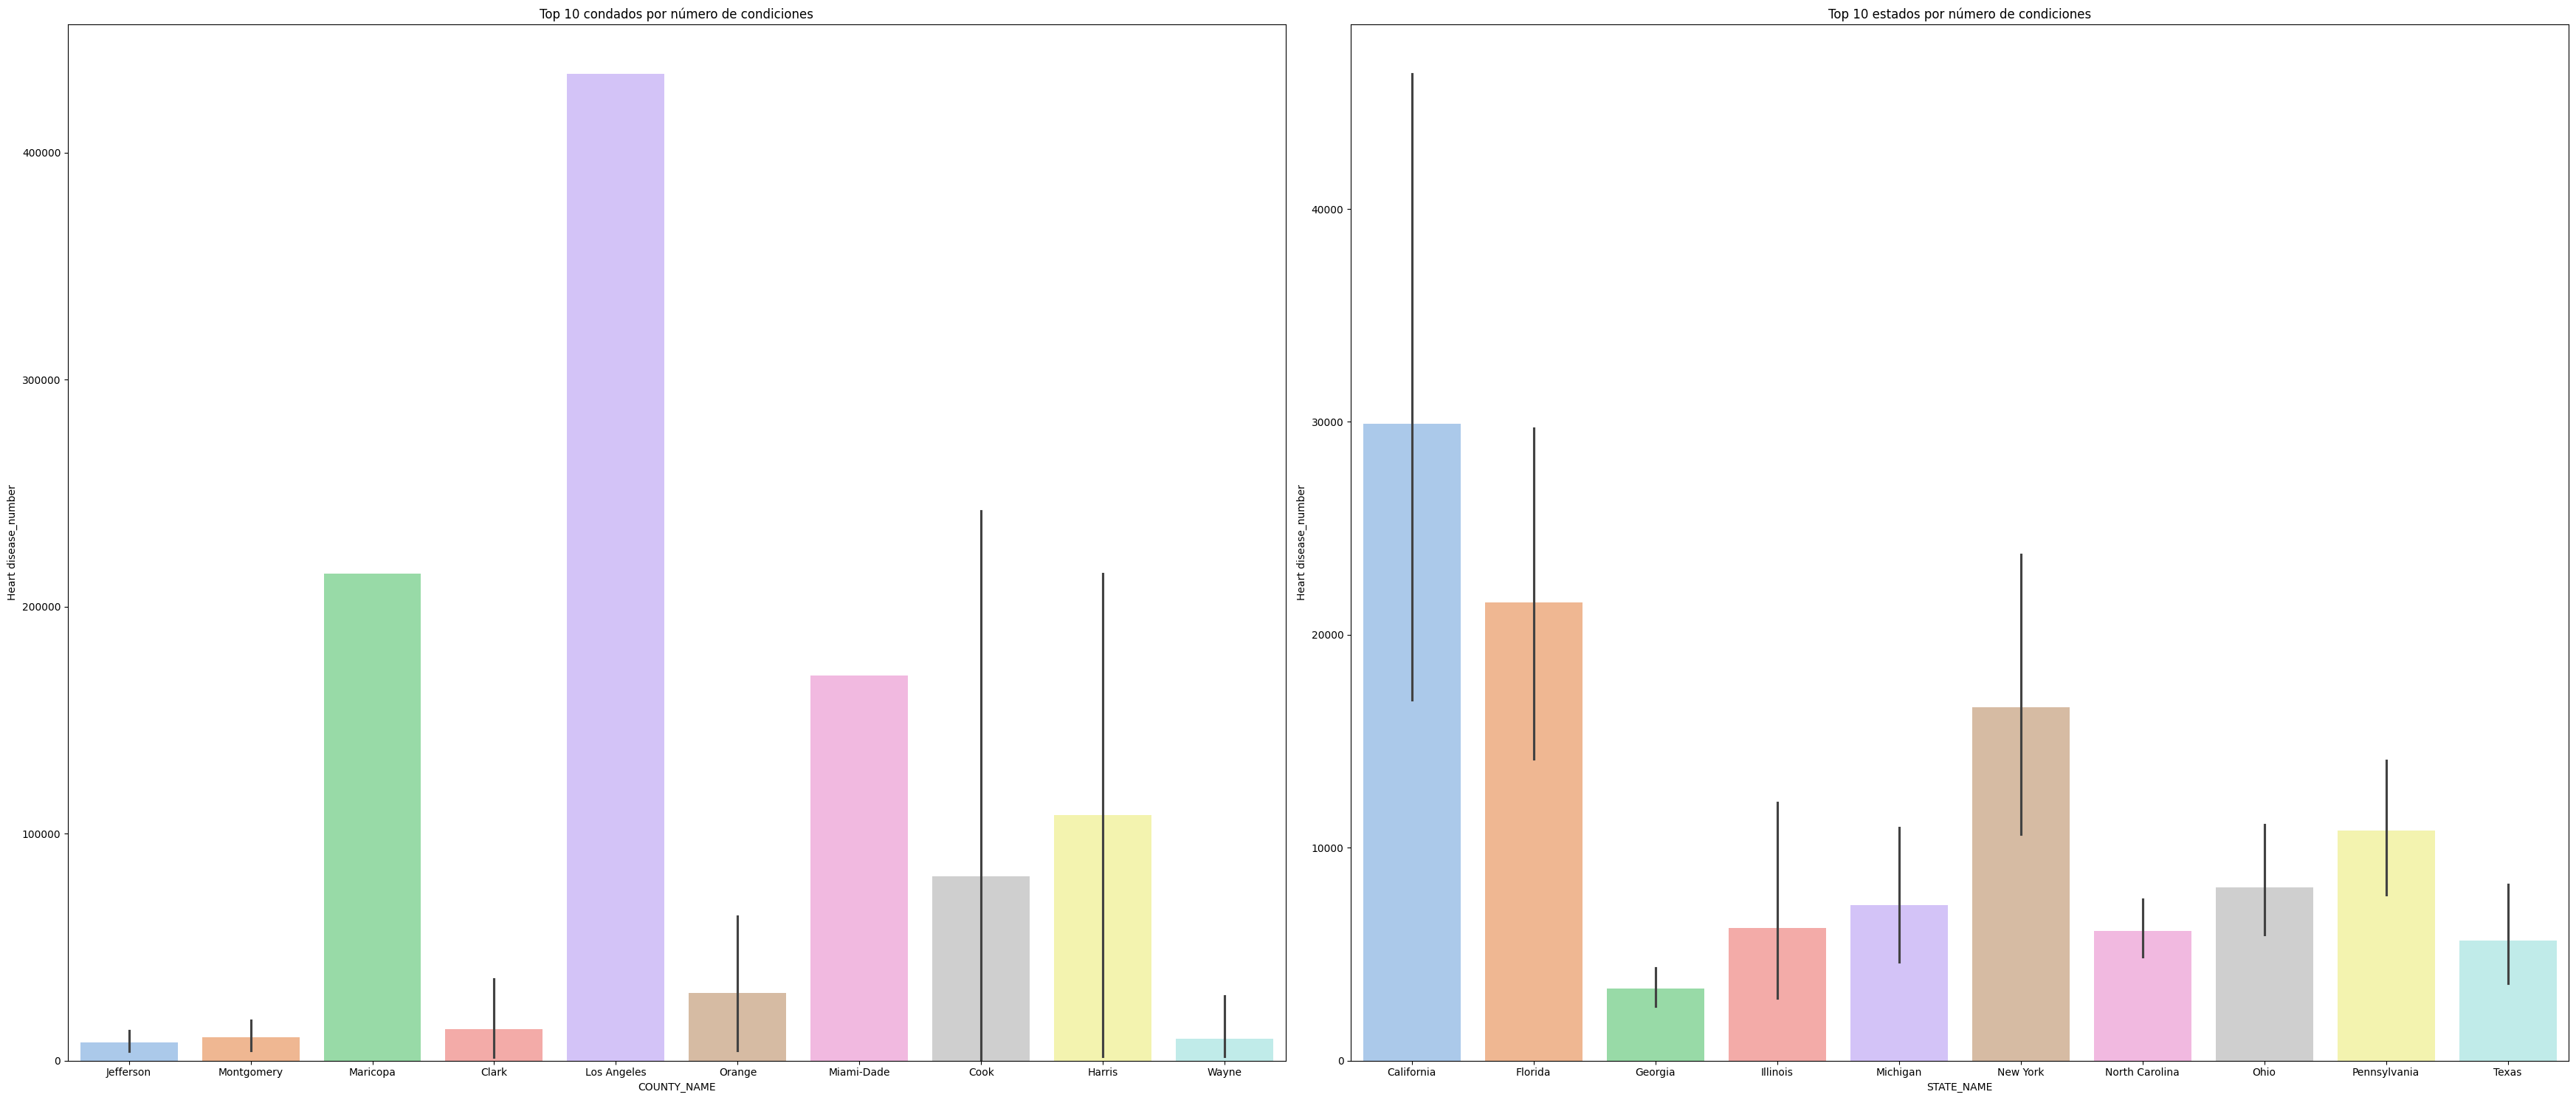

In [9]:
# Top 10 counties con más casos
top_counties = df.groupby("COUNTY_NAME")["Heart disease_number"].sum().nlargest(10).index
top_states = df.groupby("STATE_NAME")["Heart disease_number"].sum().nlargest(10).index

fig, axis = plt.subplots(1, 2, figsize = (35, 15))

sns.barplot(ax = axis[0], data = df[df["COUNTY_NAME"].isin(top_counties)],
            x = "COUNTY_NAME", y = "Heart disease_number", palette="pastel")
axis[0].set_title("Top 10 condados por número de condiciones")

sns.barplot(ax = axis[1], data = df[df["STATE_NAME"].isin(top_states)],
            x = "STATE_NAME", y = "Heart disease_number", palette="pastel")
axis[1].set_title("Top 10 estados por número de condiciones")

plt.tight_layout()
plt.show()

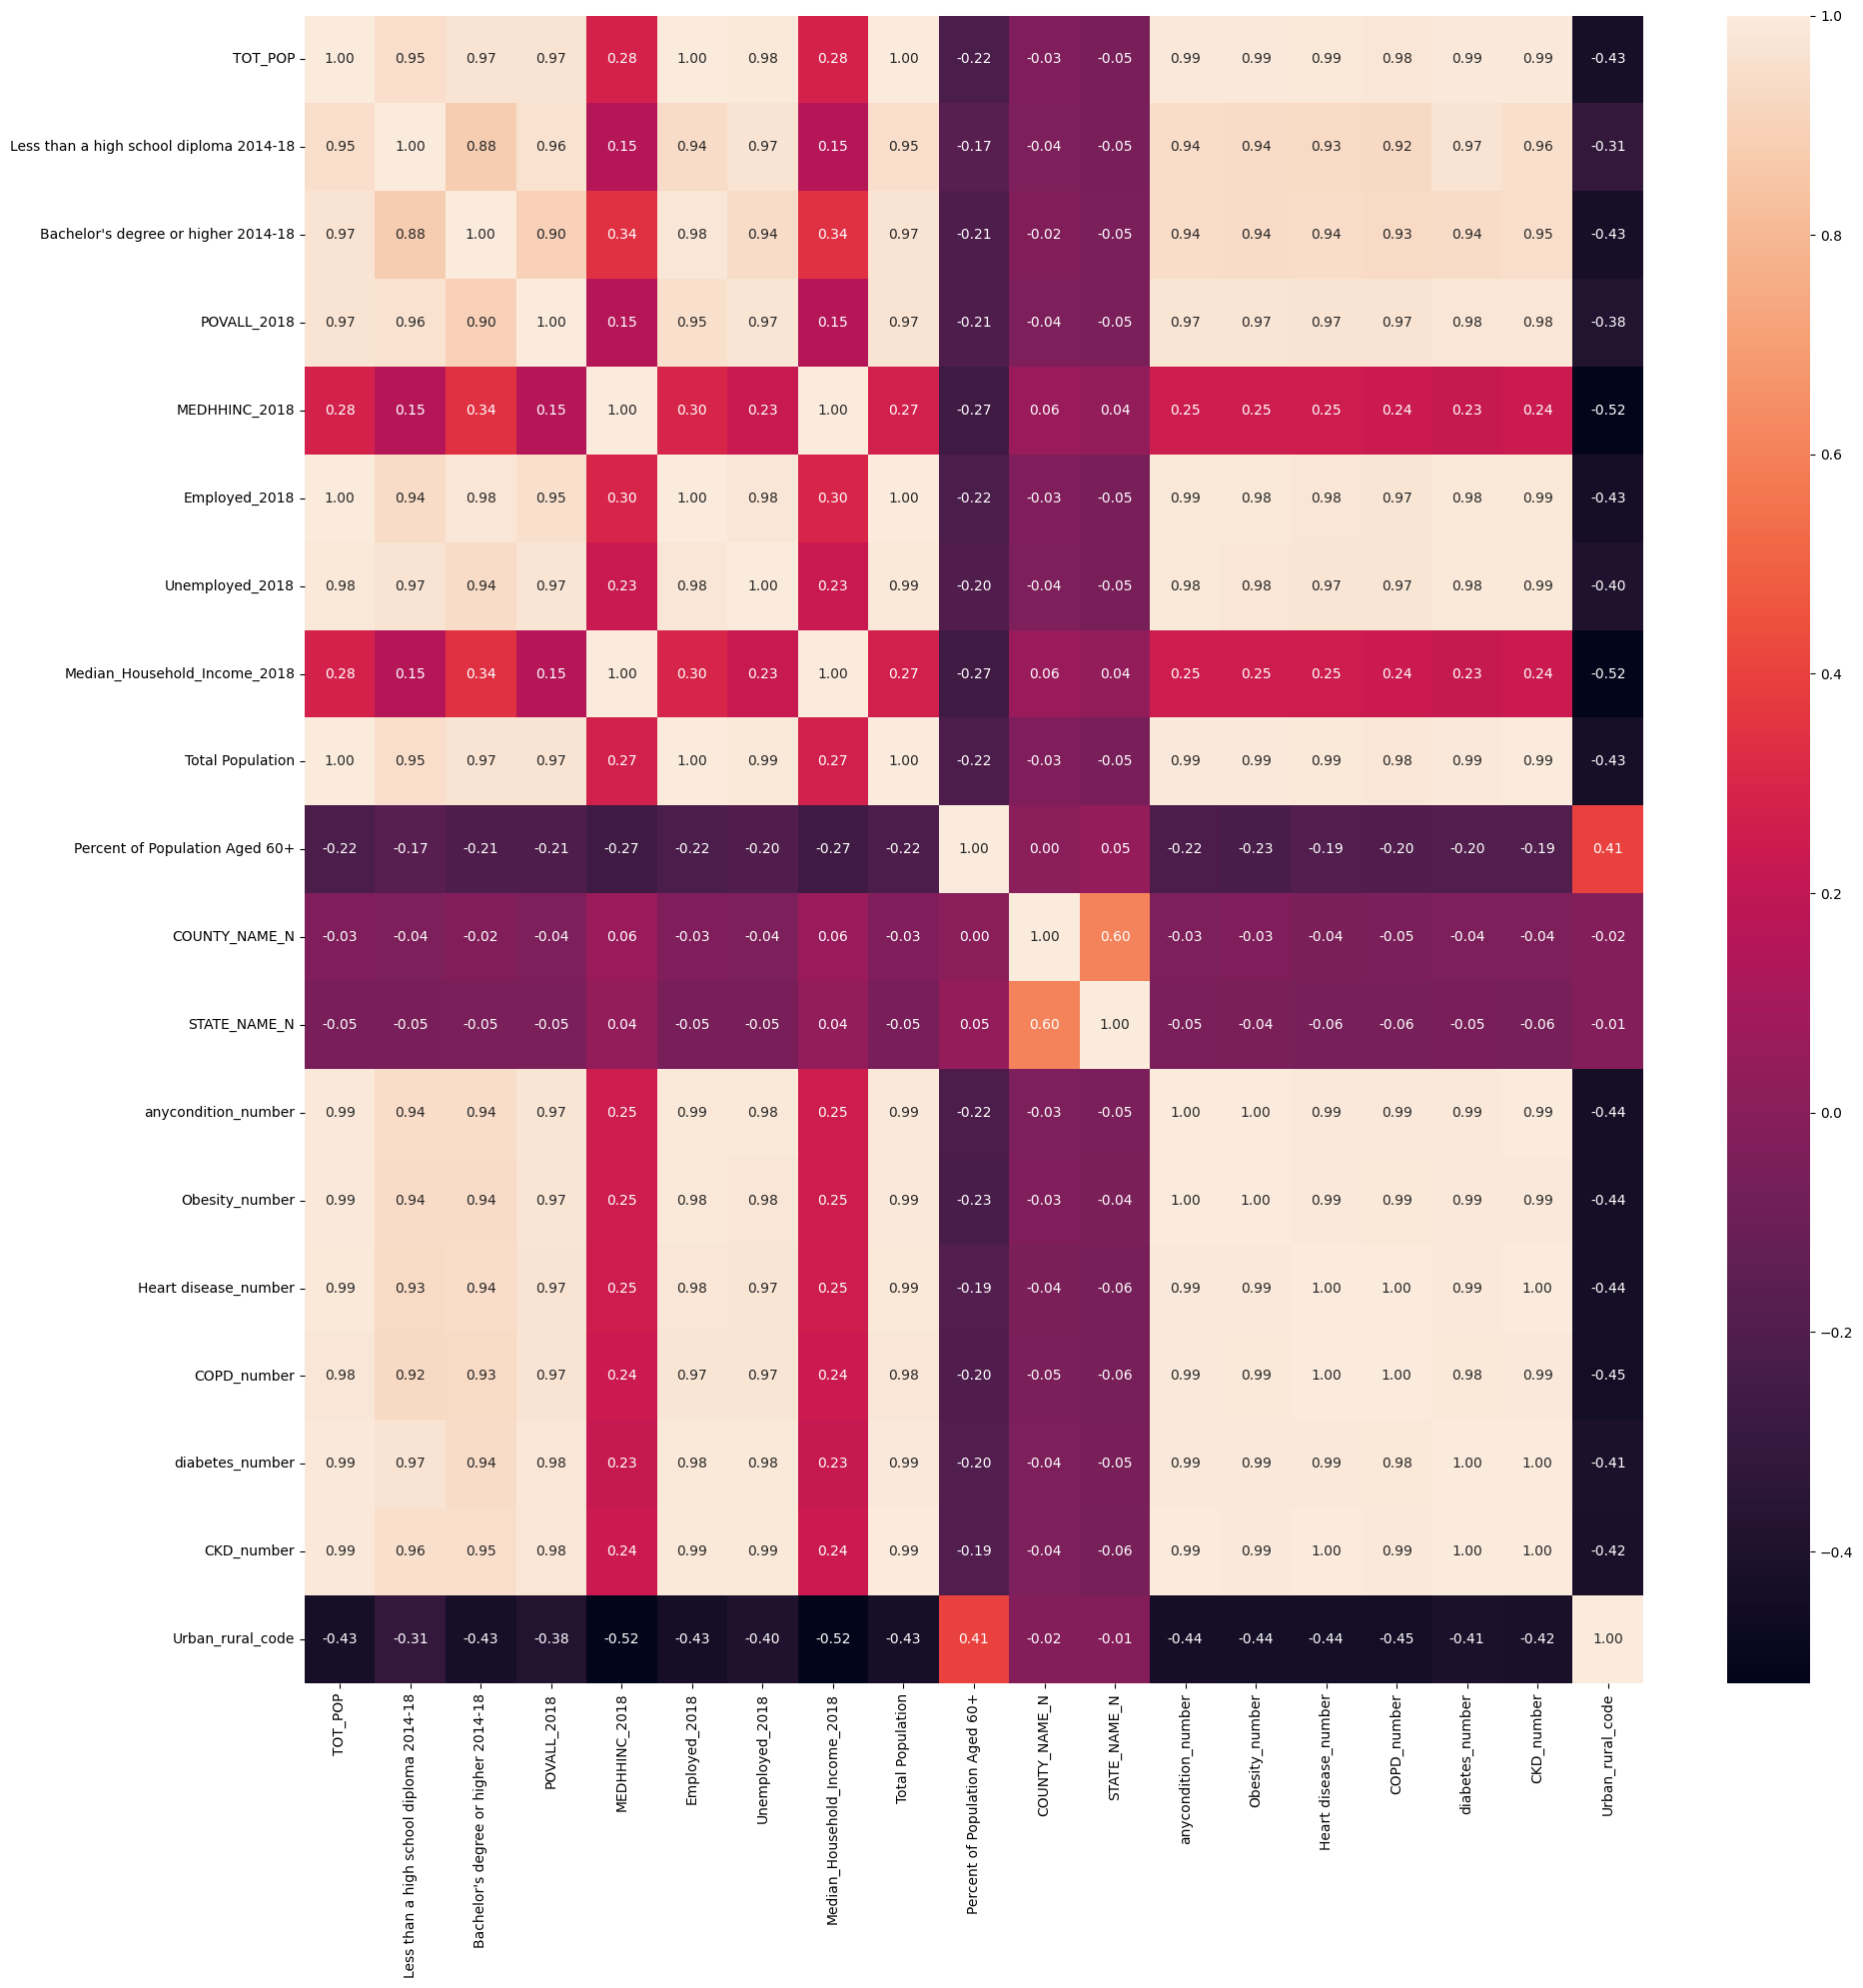

In [10]:
df["STATE_NAME_N"] = pd.factorize(df["STATE_NAME"])[0]
df["COUNTY_NAME_N"] = pd.factorize(df["COUNTY_NAME"])[0]


fig, axis = plt.subplots(figsize = (20, 20))

sns.heatmap(df[['TOT_POP', 'Less than a high school diploma 2014-18', "Bachelor's degree or higher 2014-18", 'POVALL_2018', 'MEDHHINC_2018', 'Employed_2018', 'Unemployed_2018','Median_Household_Income_2018', 'Total Population', 'Percent of Population Aged 60+', 'COUNTY_NAME_N', 'STATE_NAME_N','anycondition_number', 'Obesity_number','Heart disease_number','COPD_number','diabetes_number', 'CKD_number', 'Urban_rural_code' ]].corr(), annot = True, fmt = ".2f")

plt.tight_layout()

plt.show()

In [11]:
df.describe().round(2)

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code,STATE_NAME_N,COUNTY_NAME_N
count,3140.00,3140.00,3140.0,3140.00,3140.00,3140.00,3140.00,3140.00,3140.00,3140.00,...,3140.00,3140.00,3140.00,3140.00,3140.00,3140.00,3140.00,3140.00,3140.00,3140.00
mean,30401.64,104189.41,12740.3,11.87,13367.98,12.69,14469.33,12.28,13916.49,11.75,...,12.09,14.05,9326.58,3.45,3.21,3.71,2466.23,4.64,26.25,688.48
std,15150.56,333583.40,41807.3,2.12,42284.39,1.82,49577.73,3.13,48990.95,1.70,...,2.62,2.82,29754.60,0.57,0.53,0.61,7730.42,1.51,14.26,541.77
min,1001.00,88.00,0.0,0.00,0.00,0.00,0.00,0.00,11.00,6.09,...,5.50,6.70,11.00,1.80,1.70,1.90,3.00,1.00,0.00,0.00
25%,18180.50,10963.25,1280.5,10.59,1374.50,11.67,1263.75,10.50,1232.75,10.69,...,10.30,12.10,1187.75,3.10,2.90,3.30,314.75,3.00,14.00,182.00
50%,29178.00,25800.50,3057.0,11.80,3274.00,12.69,3108.00,11.77,3000.50,11.58,...,11.80,13.80,2743.00,3.40,3.20,3.70,718.00,5.00,25.00,564.00
75%,45081.50,67913.00,8097.0,12.95,8822.25,13.66,8976.25,13.18,8314.25,12.64,...,13.70,15.90,6679.25,3.80,3.50,4.10,1776.25,6.00,40.00,1129.25
max,56045.00,10105518.00,1208253.0,25.46,1239139.00,23.30,1557073.00,37.57,1501844.00,22.23,...,24.20,27.00,952335.00,6.20,5.80,6.60,237766.00,6.00,50.00,1840.00


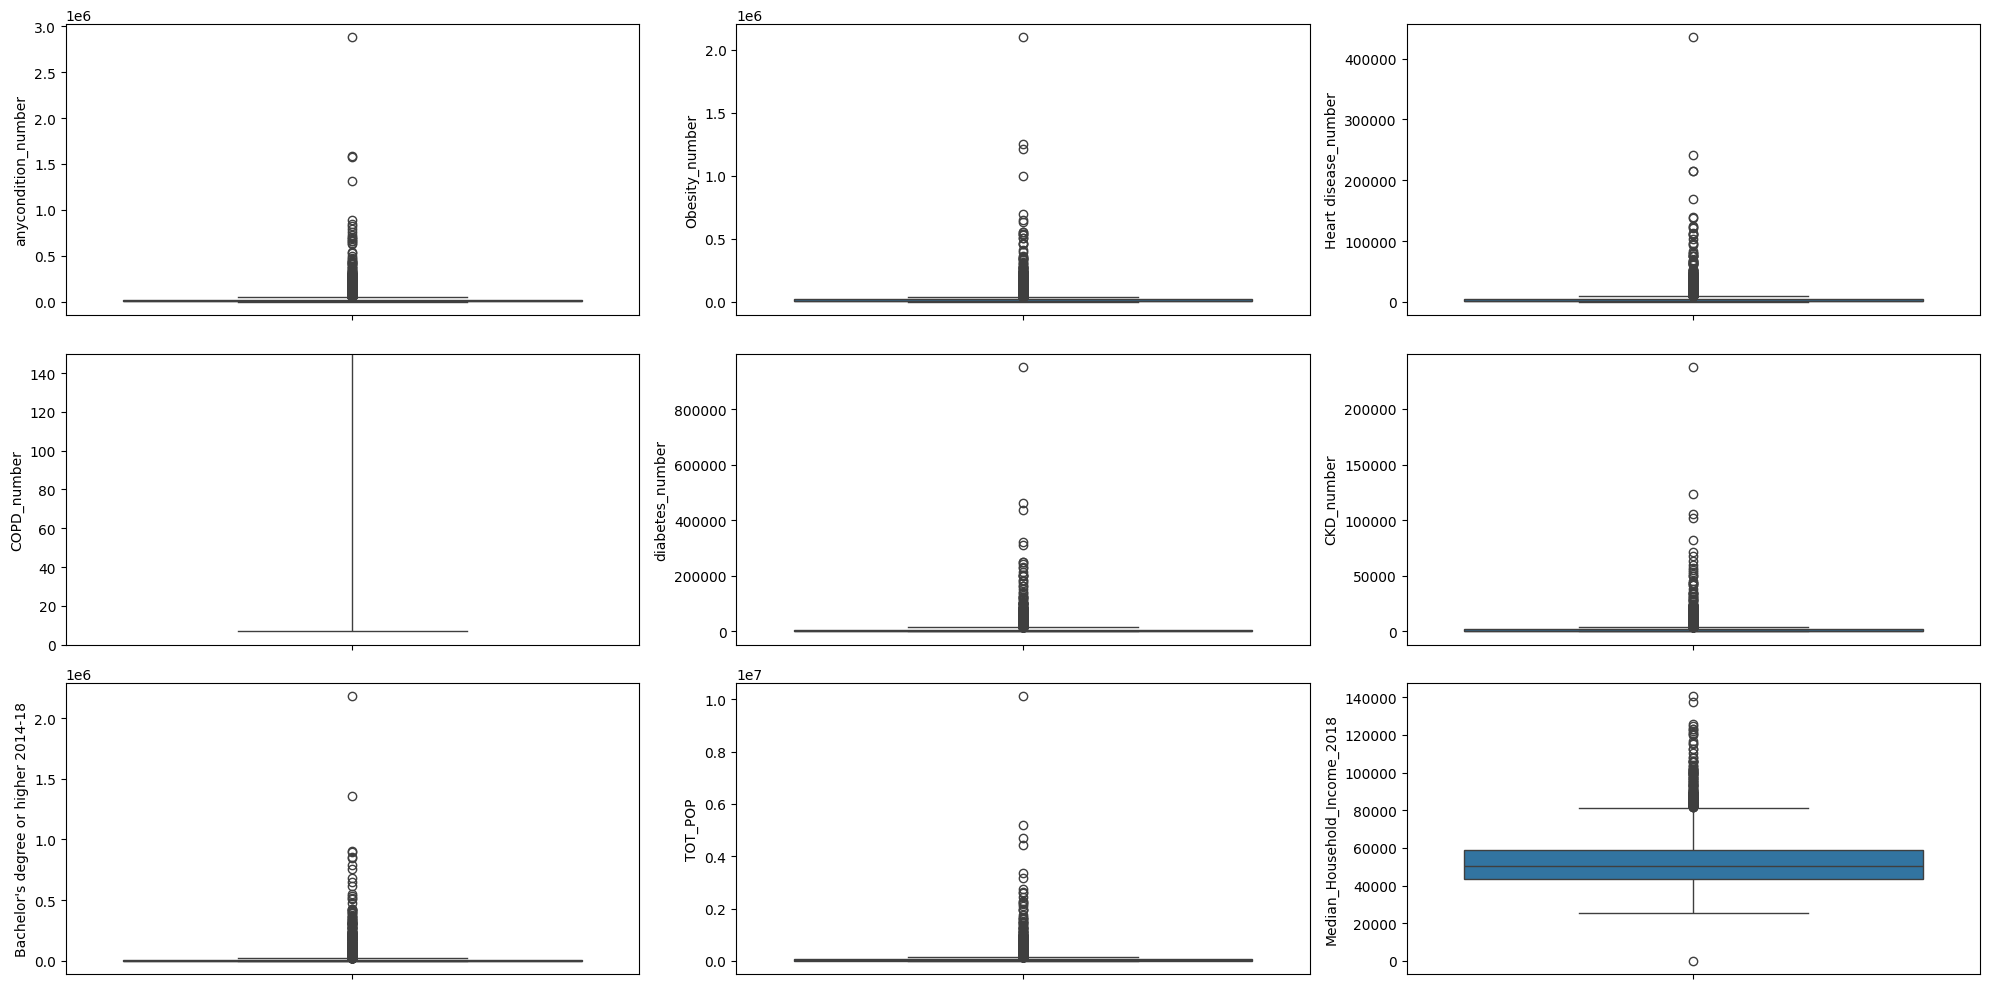

In [12]:
fig, axis = plt.subplots(3, 3, figsize = (20, 10))

sns.boxplot(ax = axis[0, 0], data = df, y = "anycondition_number")
sns.boxplot(ax = axis[0, 1], data = df, y = "Obesity_number")
sns.boxplot(ax = axis[0, 2], data = df, y = "Heart disease_number")
sns.boxplot(ax = axis[1, 0], data = df, y = "COPD_number")
axis[1, 0].set_ylim(0, 150)
sns.boxplot(ax = axis[1, 1], data = df, y = "diabetes_number")
sns.boxplot(ax = axis[1, 2], data = df, y = "CKD_number")
sns.boxplot(ax = axis[2, 0], data = df, y = "Bachelor's degree or higher 2014-18")
sns.boxplot(ax = axis[2, 1], data = df, y = "TOT_POP")
sns.boxplot(ax = axis[2, 2], data = df, y = "Median_Household_Income_2018")

plt.tight_layout()

plt.show()